In [1]:
import pandas as pd

df = pd.read_csv("data/raw/ks-projects-201801.csv")
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 378661
Columns: 15


In [3]:
print("Category:", df["category"].nunique())
print("Main category:", df["main_category"].nunique())
print("Currency:", df["currency"].nunique())

currency = df["currency"].value_counts()
print("Top currency:", currency.index[0], currency.iloc[0])


Category: 159
Main category: 15
Currency: 14
Top currency: USD 295365


In [4]:
data = df[
    df["state"].isin(["successful", "failed"]) &
    (df["currency"] == "USD")
].copy()

print("Rows:", len(data))
print(data["state"].value_counts())

Rows: 261511
state
failed        152132
successful    109379
Name: count, dtype: int64


In [5]:
data["target"] = (data["state"] == "successful").astype(int)
print(data["target"].value_counts())

target
0    152132
1    109379
Name: count, dtype: int64


In [6]:
data["launched"] = pd.to_datetime(data["launched"])
data["deadline"] = pd.to_datetime(data["deadline"])
data["duration"] = (data["deadline"] - data["launched"]).dt.total_seconds() / 86400

print(data["duration"].describe())

count    261511.000000
mean         33.627022
std          13.014816
min           0.005058
25%          29.090833
50%          29.743588
75%          36.349531
max          91.962650
Name: duration, dtype: float64


In [7]:
categories = pd.get_dummies(data["main_category"], dtype=int)
categories.head()

,Art,Comics,Crafts,Dance,Design,Fashion,Film & Video,Food,Games,Journalism,Music,Photography,Publishing,Technology,Theater
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [8]:
X = pd.concat([data[["goal", "duration"]], categories], axis=1)
y = data["target"]

print("X:", X.shape)
print("y:", y.shape)

X: (261511, 17)
y: (261511,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1001, stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 209208
Test: 52303


In [10]:
from adalineGD import AdalineGD

ada = AdalineGD(eta=0.001, n_iter=50)
ada.fit(X_train.to_numpy(), y_train.to_numpy())

print("First loss:", ada.losses_[0])
print("Last loss:", ada.losses_[-1])

First loss: 294496505.7355288
Last loss: nan


/Users/weston/dev/IDSN542/assignment-2-kickstarter/adalineGD.py:52: RuntimeWarning: overflow encountered in square
  loss = (errors**2).mean()
/Users/weston/dev/IDSN542/assignment-2-kickstarter/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/weston/dev/IDSN542/assignment-2-kickstarter/adalineGD.py:40: RuntimeWarning: invalid value encountered in add
  self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]


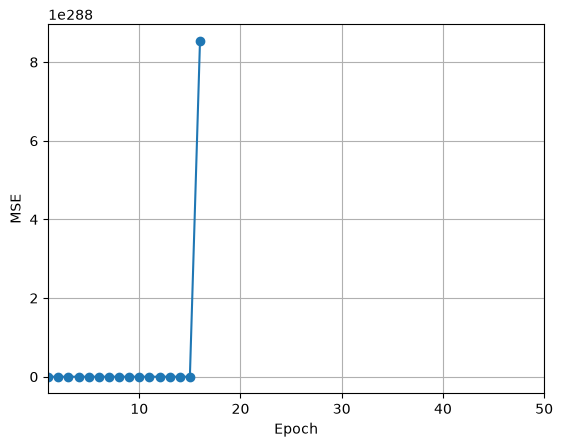

In [11]:
import numpy as np
import matplotlib.pyplot as plt

loss = np.array(ada.losses_)
loss[~np.isfinite(loss)] = np.nan

plt.plot(range(1, len(loss) + 1), loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.xlim(1, len(loss))
plt.grid()
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

cols = ["goal", "duration"]
scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[cols] = scaler.fit_transform(X_train[cols])
X_test_std[cols] = scaler.transform(X_test[cols])

X_train_std[cols].head()

,goal,duration
31796,-0.035883,-0.291879
113281,-0.031621,0.435783
24392,-0.027832,0.353248
176257,-0.034936,0.857539
219909,-0.035883,-0.403058


In [ ]:
ada_std = AdalineGD(eta=0.001, n_iter=50)
ada_std.fit(X_train_std.to_numpy(), y_train.to_numpy())

y_pred = ada_std.predict(X_test_std.to_numpy())

print("First loss:", ada_std.losses_[0])
print("Last loss:", ada_std.losses_[-1])
print("Train accuracy:", (ada_std.predict(X_train_std.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred == y_test).mean())


First loss: 0.4174580430666756
Last loss: 0.38270726885517503
Train accuracy: 0.5815838782455738
Test accuracy: 0.5816109974571249
Predicted successful: 7
Always fail accuracy: 0.5817448329923713


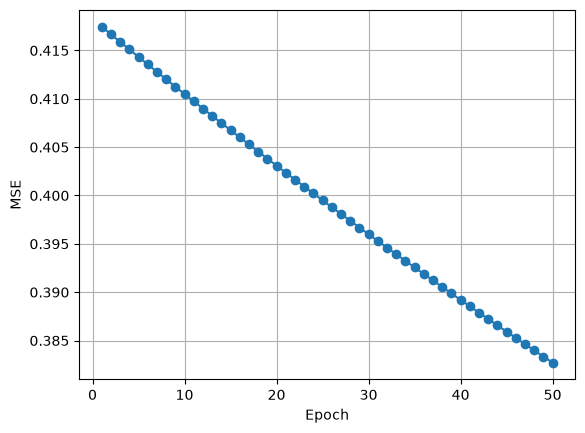

In [14]:
plt.plot(range(1, len(ada_std.losses_) + 1), ada_std.losses_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [15]:
ada_std = AdalineGD(eta=0.001, n_iter=500)
ada_std.fit(X_train_std.to_numpy(), y_train.to_numpy())

y_pred = ada_std.predict(X_test_std.to_numpy())

print("First loss:", ada_std.losses_[0])
print("Last loss:", ada_std.losses_[-1])
print("Train accuracy:", (ada_std.predict(X_train_std.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred == y_test).mean())

First loss: 0.4174580430666756
Last loss: 0.25780823529362473
Train accuracy: 0.5817416159993881
Test accuracy: 0.5817448329923713


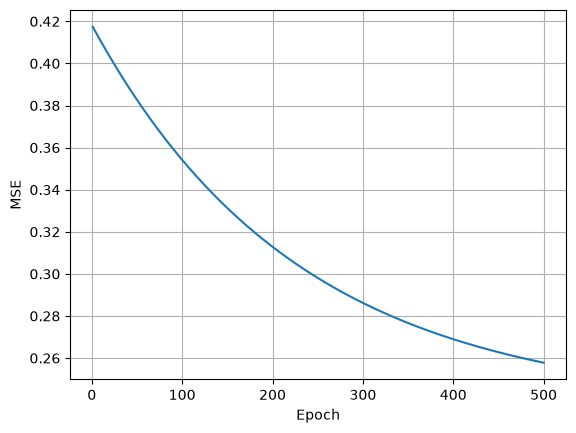

In [16]:
plt.plot(range(1, len(ada_std.losses_) + 1), ada_std.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [17]:
ada_2000 = AdalineGD(eta=0.001, n_iter=2000)
ada_2000.fit(X_train_std.to_numpy(), y_train.to_numpy())

y_pred = ada_2000.predict(X_test_std.to_numpy())

print("First loss:", ada_2000.losses_[0])
print("Last loss:", ada_2000.losses_[-1])
print("Train accuracy:", (ada_2000.predict(X_train_std.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred == y_test).mean())

First loss: 0.4174580430666756
Last loss: 0.2354270292972662
Train accuracy: 0.5965546250621391
Test accuracy: 0.5978242165841348


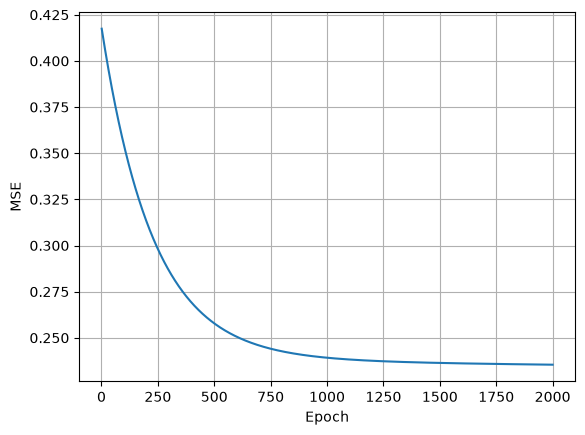

In [18]:
plt.plot(range(1, len(ada_2000.losses_) + 1), ada_2000.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [19]:
ada_lr = AdalineGD(eta=0.01, n_iter=2000)
ada_lr.fit(X_train_std.to_numpy(), y_train.to_numpy())

y_pred = ada_lr.predict(X_test_std.to_numpy())

print("First loss:", ada_lr.losses_[0])
print("Last loss:", ada_lr.losses_[-1])
print("Train accuracy:", (ada_lr.predict(X_train_std.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred == y_test).mean())

First loss: 0.4174580430666756
Last loss: 0.22955667986506895
Train accuracy: 0.6241778517073917
Test accuracy: 0.625432575569279


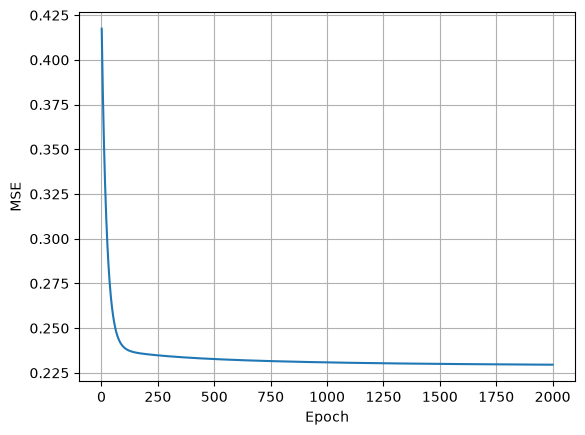

In [20]:
plt.plot(range(1, len(ada_lr.losses_) + 1), ada_lr.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

In [21]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()

X_train_log["goal"] = np.log1p(X_train_log["goal"])
X_test_log["goal"] = np.log1p(X_test_log["goal"])

scaler_log = StandardScaler()
X_train_log[cols] = scaler_log.fit_transform(X_train_log[cols])
X_test_log[cols] = scaler_log.transform(X_test_log[cols])

In [22]:
ada_log = AdalineGD(eta=0.01, n_iter=2000)
ada_log.fit(X_train_log.to_numpy(), y_train.to_numpy())

y_pred = ada_log.predict(X_test_log.to_numpy())

print("First loss:", ada_log.losses_[0])
print("Last loss:", ada_log.losses_[-1])
print("Train accuracy:", (ada_log.predict(X_train_log.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred == y_test).mean())

First loss: 0.42055775348509017
Last loss: 0.22171362021098898
Train accuracy: 0.6395740124660625
Test accuracy: 0.6384146224881938


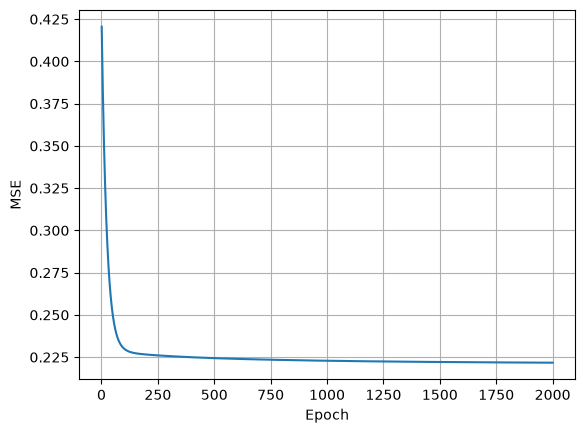

In [23]:
plt.plot(range(1, len(ada_log.losses_) + 1), ada_log.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

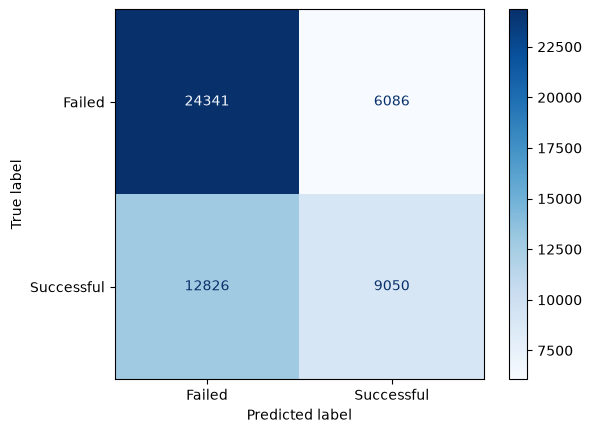

Failed recall: 0.7999802806717717
Successful recall: 0.4136953739257634


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = ada_log.predict(X_test_log.to_numpy())
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

ConfusionMatrixDisplay(cm, display_labels=["Failed", "Successful"]).plot(cmap="Blues", values_format="d")
plt.show()

print("Failed recall:", cm[0, 0] / cm[0].sum())
print("Successful recall:", cm[1, 1] / cm[1].sum())

In [25]:
category = pd.get_dummies(data["category"], prefix="category", dtype=int)

X_train_cat = pd.concat([X_train_log, category.loc[X_train_log.index]], axis=1)
X_test_cat = pd.concat([X_test_log, category.loc[X_test_log.index]], axis=1)

print("Features:", X_train_cat.shape[1])

Features: 176


In [26]:
ada_cat = AdalineGD(eta=0.01, n_iter=2000)
ada_cat.fit(X_train_cat.to_numpy(), y_train.to_numpy())

y_pred_cat = ada_cat.predict(X_test_cat.to_numpy())

print("First loss:", ada_cat.losses_[0])
print("Last loss:", ada_cat.losses_[-1])
print("Train accuracy:", (ada_cat.predict(X_train_cat.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred_cat == y_test).mean())

First loss: 0.41988827757593883
Last loss: 0.2153035260870503
Train accuracy: 0.656695728652824
Test accuracy: 0.6571898361470662


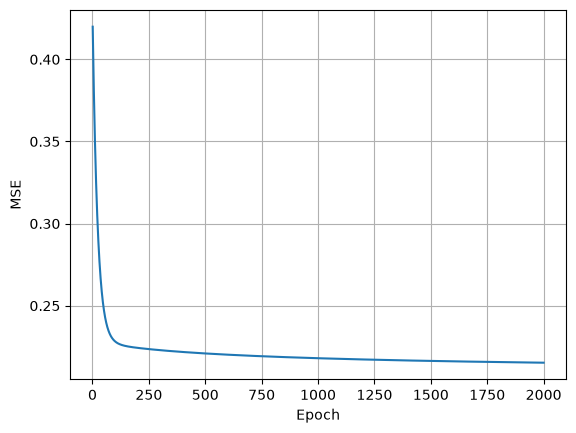

In [27]:
plt.plot(range(1, len(ada_cat.losses_) + 1), ada_cat.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

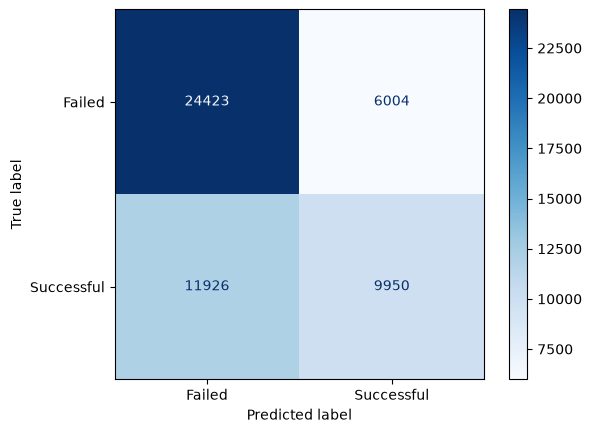

Failed recall: 0.8026752555296283
Successful recall: 0.45483635033827025


In [28]:
cm_cat = confusion_matrix(y_test, y_pred_cat, labels=[0, 1])

ConfusionMatrixDisplay(cm_cat, display_labels=["Failed", "Successful"]).plot(cmap="Blues", values_format="d")
plt.show()

print("Failed recall:", cm_cat[0, 0] / cm_cat[0].sum())
print("Successful recall:", cm_cat[1, 1] / cm_cat[1].sum())

In [29]:
X_train_sub = X_train_cat.drop(columns=categories.columns)
X_test_sub = X_test_cat.drop(columns=categories.columns)

print("Features:", X_train_sub.shape[1])

Features: 161


In [30]:
ada_sub = AdalineGD(eta=0.01, n_iter=2000)
ada_sub.fit(X_train_sub.to_numpy(), y_train.to_numpy())

y_pred_sub = ada_sub.predict(X_test_sub.to_numpy())

print("First loss:", ada_sub.losses_[0])
print("Last loss:", ada_sub.losses_[-1])
print("Train accuracy:", (ada_sub.predict(X_train_sub.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred_sub == y_test).mean())

First loss: 0.4217493850805859
Last loss: 0.21783789876891374
Train accuracy: 0.6474226607013116
Test accuracy: 0.6459094124620003


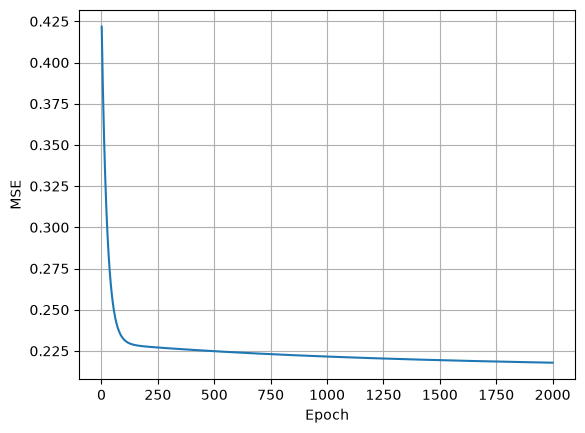

In [31]:
plt.plot(range(1, len(ada_sub.losses_) + 1), ada_sub.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

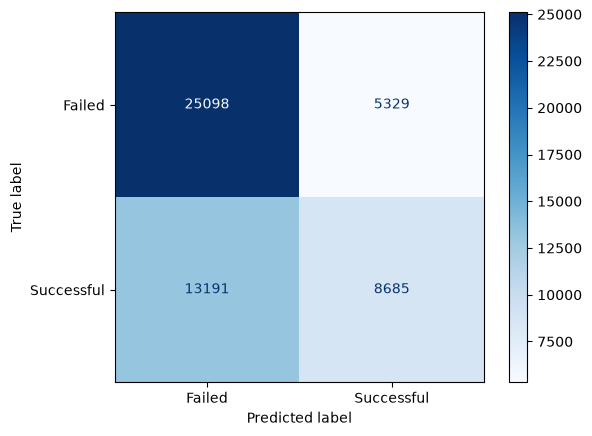

Failed recall: 0.824859499786374
Successful recall: 0.3970104223806912


In [32]:
cm_sub = confusion_matrix(y_test, y_pred_sub, labels=[0, 1])

ConfusionMatrixDisplay(cm_sub, display_labels=["Failed", "Successful"]).plot(cmap="Blues", values_format="d")
plt.show()

print("Failed recall:", cm_sub[0, 0] / cm_sub[0].sum())
print("Successful recall:", cm_sub[1, 1] / cm_sub[1].sum())

In [33]:
X_train_main2 = X_train_cat.copy()
X_test_main2 = X_test_cat.copy()

X_train_main2[categories.columns] *= 2
X_test_main2[categories.columns] *= 2

In [34]:
ada_main2 = AdalineGD(eta=0.01, n_iter=2000)
ada_main2.fit(X_train_main2.to_numpy(), y_train.to_numpy())

y_pred_main2 = ada_main2.predict(X_test_main2.to_numpy())

print("First loss:", ada_main2.losses_[0])
print("Last loss:", ada_main2.losses_[-1])
print("Train accuracy:", (ada_main2.predict(X_train_main2.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred_main2 == y_test).mean())

First loss: 0.41931733328823323
Last loss: 0.21490170305363826
Train accuracy: 0.657006424228519
Test accuracy: 0.6587385044834905


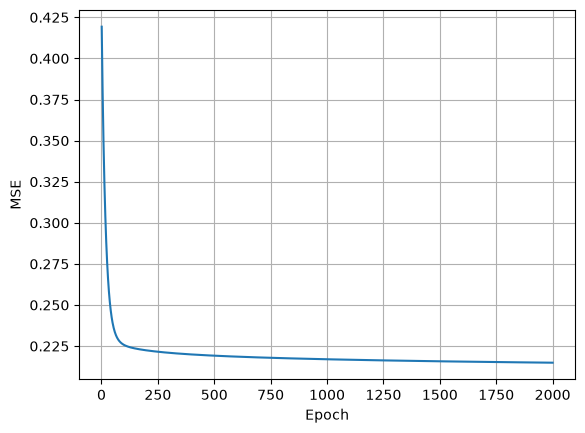

In [35]:
plt.plot(range(1, len(ada_main2.losses_) + 1), ada_main2.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

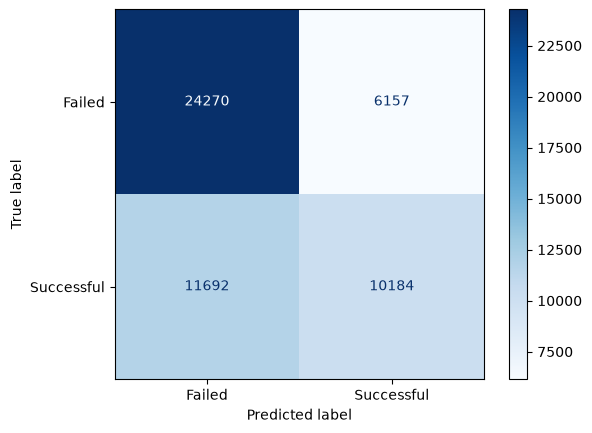

Failed recall: 0.7976468268314326
Successful recall: 0.465533004205522


In [36]:
cm_main2 = confusion_matrix(y_test, y_pred_main2, labels=[0, 1])

ConfusionMatrixDisplay(cm_main2, display_labels=["Failed", "Successful"]).plot(cmap="Blues", values_format="d")
plt.show()

print("Failed recall:", cm_main2[0, 0] / cm_main2[0].sum())
print("Successful recall:", cm_main2[1, 1] / cm_main2[1].sum())

In [15]:
ada_10000 = AdalineGD(eta=0.01, n_iter=10000)
ada_10000.fit(X_train_main2.to_numpy(), y_train.to_numpy())

y_pred_10000 = ada_10000.predict(X_test_main2.to_numpy())

print("First loss:", ada_10000.losses_[0])
print("Last loss:", ada_10000.losses_[-1])
print("Train accuracy:", (ada_10000.predict(X_train_main2.to_numpy()) == y_train).mean())
print("Test accuracy:", (y_pred_10000 == y_test).mean())

First loss: 0.41931733328823323
Last loss: 0.21162249438629663
Train accuracy: 0.6619297541203013
Test accuracy: 0.6621417509511883


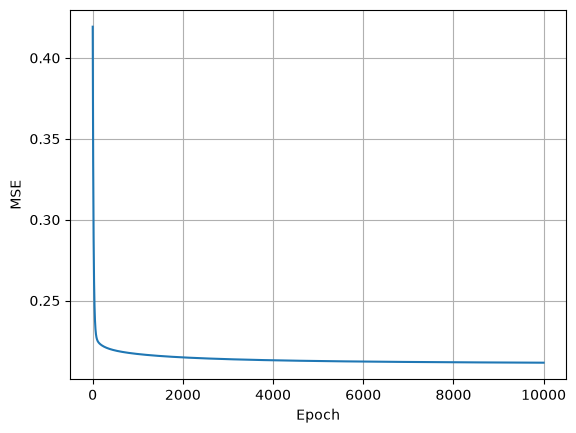

In [16]:
plt.plot(range(1, len(ada_10000.losses_) + 1), ada_10000.losses_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid()
plt.show()

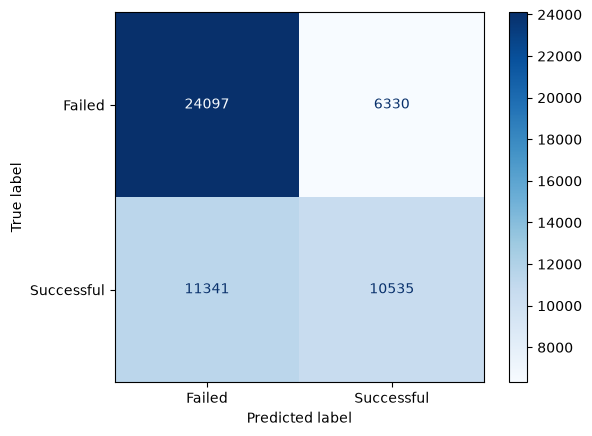

Failed recall: 0.7919610871922963
Successful recall: 0.4815779850063997


In [17]:
cm_10000 = confusion_matrix(y_test, y_pred_10000, labels=[0, 1])

ConfusionMatrixDisplay(cm_10000, display_labels=["Failed", "Successful"]).plot(cmap="Blues", values_format="d")
plt.show()

print("Failed recall:", cm_10000[0, 0] / cm_10000[0].sum())
print("Successful recall:", cm_10000[1, 1] / cm_10000[1].sum())